# Run this to enable loading from relative packes

In [1]:
%load_ext autoreload
%autoreload 2
if "PKG" not in globals():
    root_parent_level = 2
    import importlib, sys, pathlib # https://stackoverflow.com/a/50395128/11996983
    PKG = %pwd
    PKG = pathlib.Path(PKG)
    root = PKG
    full_pkg = f"{root.name}"
    for _ in range(root_parent_level):
        root = root.parent
        full_pkg = f"{root.name}.{full_pkg}"
        MODULE_PATH = f"{root}{pathlib.os.path.sep}__init__.py"
        MODULE_NAME = f"{root.name}"
        spec = importlib.util.spec_from_file_location(MODULE_NAME, MODULE_PATH)
        module = importlib.util.module_from_spec(spec)
        sys.modules[spec.name] = module
        spec.loader.exec_module(module)
    __package__ = full_pkg


In [2]:
# This is necessary for interactive plots in Jupyter notebooks
%matplotlib widget

# Save plots with no embeded fonts

In [3]:
import matplotlib.pyplot as plt
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]


# Load all mice data

In [4]:
from .model_runner import loadDF, _extendTrials, _reduceDFSize
from ..behavior.rewardrate import calcAvgRewardRate
# Here we load the behavior dataframe, however we leave in all the trials and
# calculate the loss function only on valid trials. The reason we leave the
# non-valid in is that we need the full history to see the progression of animal
# choices from one trial to the next.
df_behavior = loadDF()
print("Calculate average reward rate (and create SessId column)...")
df_behavior = calcAvgRewardRate(df_behavior)
print("Reduce dataframe size to speed up df operations...")
df_behavior = _reduceDFSize(df_behavior)
# We make all the sessions have the same number of trials by extending the
# trials with invalid trials at the end. This is necessary for to be able to
# vectorize the model simulation across all sessions.
# The appended trials are marked as invalid and do not contribute to the
# loss function.
print("Extend trial such that all sessions have the same number of trials...")
df_behavior = _extendTrials(df_behavior)

Nullifying: 4,181/82,389 trials with calcStimulusTime > 3s (of which 2,347 are valid trials)
Calculate average reward rate (and create SessId column)...
Reduce dataframe size to speed up df operations...
Extend trial such that all sessions have the same number of trials...


# Load Results

In [5]:
import pickle
from pathlib import Path

def loadAll():
    evolve_res_dict_dict = {}
    all_sunjects = df_behavior.Name.unique()
    for fp in Path("../../data/RLModel").iterdir():
        # print("Processing:", fp)
        if not fp.is_file() or not (#fp.name.startswith("evolvs_") and 
                                    fp.name.endswith(".pkl")):
            continue
        with fp.open("rb") as f:
            _evolve_loaded = pickle.load(f)
            evolve_res_dict_dict[fp.name] = _evolve_loaded
            missing_subjects = {key for key in all_sunjects
                                if key not in _evolve_loaded}
            if missing_subjects:
                print("Missing subjects:", missing_subjects, "from file:", fp)
        # _evolve_loaded = pd.read_pickle(fp)
        evolve_res_dict_dict[fp.name] = _evolve_loaded
            
    return evolve_res_dict_dict

# The structure is:
# {
#   "model_name.pkl": {
#        "subject_name": subject_model_res_dict
#    }
# }
# Refer to rlmodel/README.md for structure of subject_model_res_dict
evolve_res_dict_dict = loadAll()

Copy the fit values to the GUI cache such that each subject would be loaded 
with model optimized values 

In [6]:
from .model.drift import DRIFT_FN_DICT
from .model.noise import NOISE_FN_DICT
from .model.bias import BIAS_FN_DICT
import numpy as np

# Copy the results to the cache
def assignGUISubjectsDefaults(evolve_res_dict_dict, skip_loss_no_dir=True):
    subjects_defaults = {}

    for filename, evolvs_res_dict in evolve_res_dict_dict.items():
        # e.g filename: evolvs_res_dump_Constant Q-RewardRate (SEP NDT)_biasNone__Normal(0, 1)_3s_dt0.005.pkl 
        print("Processing:", filename)
        splitted = filename#.split("evolvs_res_dump_")[1]
        # print("Splitted:", splitted)
        first_char = splitted[0]
        _driftFn, splitted = splitted[1:].split("_", 1)
        _driftFn = first_char + _driftFn
        first_char = splitted[0]
        _biasFn, splitted = splitted[1:].split("_", 1)
        _biasFn = first_char + _biasFn
        if _biasFn == "biasNone":
            _biasFn = "biasNone_"
            splitted = splitted[1:]
        _biasFn = _biasFn.lstrip("bias")
        first_char = splitted[0]
        _NoiseFn, splitted = splitted[1:].split("_", 1)
        _NoiseFn = first_char + _NoiseFn

        if "loss_no_dir_" in splitted:
            loss_no_dir = True
            splitted = splitted.split("loss_no_dir_")[1]
            # print("Splitted:", splitted)
        else:
            loss_no_dir = False

        _t_dur, splitted = splitted.split("s_", 1)
        _t_dur = float(_t_dur)
        _dt = splitted.split("dt")[1].split(".pkl")[0]

        if loss_no_dir:
            raise NotImplementedError("Skip loss no dir is not incporated yet!")

        for subject, subject_res in evolvs_res_dict.items():
            cur_subject_defaults = {}
            assert len(subject_res["params_names"]) == len(subject_res["OptimRes"].x)
            # print("Subject Res:", subject_res)
            for name, val in zip(subject_res["params_names"], subject_res["OptimRes"].x):
                # print(subject, "- Setting", name, "to", val)
                cur_subject_defaults[name] = val
            lookup = {}
            for key in ("df", "driftFn", "biasFn", "noiseFn"):
                fn_idx = np.where(subject_res["fixed_params_names"] == key)[0][0]
                fn = subject_res["fixed_params_vals"][fn_idx]
                # print(f"{key}={fn_str}")
                # cur_subject_defaults[key] = fn.__name__
                lookup[key] = fn

            t_dur = subject_res["t_dur"]
            df = lookup["df"]
            
            noiseFn = NOISE_FN_DICT[_NoiseFn].__name__
            biasFn = BIAS_FN_DICT[_biasFn].__name__
            driftFn = DRIFT_FN_DICT[_driftFn].__name__            
            
            # Update the nested dictionary
            if t_dur not in subjects_defaults:
                subjects_defaults[t_dur] = {}
            if noiseFn not in subjects_defaults[t_dur]:
                subjects_defaults[t_dur][noiseFn] = {}
            if biasFn not in subjects_defaults[t_dur][noiseFn]:
                subjects_defaults[t_dur][noiseFn][biasFn] = {}
            if driftFn not in subjects_defaults[t_dur][noiseFn][biasFn]:
                subjects_defaults[t_dur][noiseFn][biasFn][driftFn] = {}
            # Ensure no overwriting of the same subject
            assert subject not in subjects_defaults[t_dur][noiseFn][biasFn][driftFn], \
                f"Subject {subject} from {filename} already exists! {t_dur}s - {noiseFn} {biasFn} {driftFn}"
            
            # Add the subject's defaults
            # print("Adding:", t_dur, noiseFn, biasFn, driftFn, subject)
            subjects_defaults[t_dur][noiseFn][biasFn][driftFn][subject] = cur_subject_defaults, df

    return subjects_defaults

# [print(fn.__name__) for fn in DRIFT_FN_DICT.values()]
subjects_defaults = assignGUISubjectsDefaults(evolve_res_dict_dict=evolve_res_dict_dict,
                                              skip_loss_no_dir=True)

Processing: Classic_biasNone__Normal(0, 1)_3s_dt0.005.pkl
Processing: Classic_biasQ-Val (Offset)_Normal(0, 1)_3s_dt0.005.pkl
Processing: Decay Q (Offset)_biasNone__Normal(0, 1)_3s_dt0.005.pkl
Processing: NoiseGain-RewardRate Decay Q (Offset)_biasNone__Normal(0, 1)_3s_dt0.005.pkl
Processing: NoiseGain-RewardRate_biasNone__Normal(0, 1)_3s_dt0.005.pkl
Processing: NoiseGain-RewardRate_biasQ-Val (Offset)_Normal(0, 1)_3s_dt0.005.pkl


# Interactive Viewer

In [ ]:
import pickle
import pathlib
# This is a very simple helper that remembers the last GUI setting used. This is
# useful when you want to share settings between runs or between code users.
# Remember to save the cache after changing settings!
GUI_CACHE_FP = pathlib.Path("model_GUI_cache.pkl")
if GUI_CACHE_FP.exists():
    print("Loading GUI cache...")
    with GUI_CACHE_FP.open("rb") as fp:
        gui_cache = pickle.load(fp)
else:
    print("No GUI cache found, starting fresh...")
    gui_cache = {}

Loading GUI cache...


In [8]:
from .model.initvals import InitVals, DT, T_dur
init_vals = InitVals()

cached_value: <function _noiseGainRewardRate at 0x0000021EFFF37740>
cached_value: <function _biasQVal at 0x0000021EFFAAE480>
cached_value: <function _noiseNormal at 0x0000021EFFF37BA0>


Output()

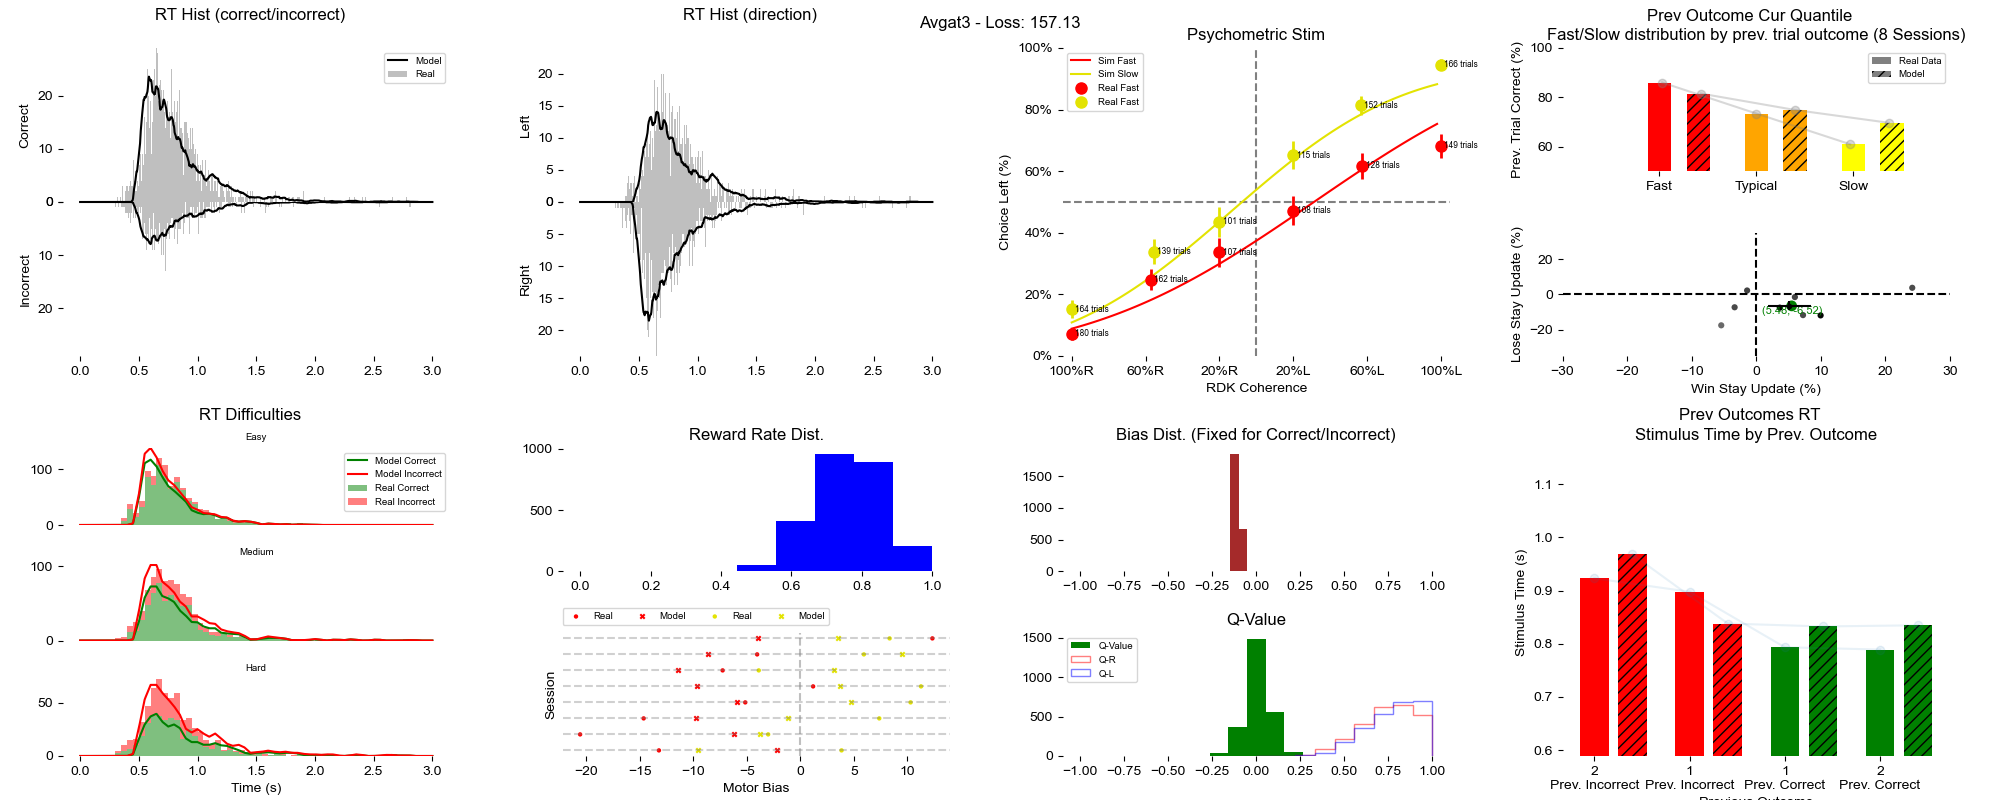

In [ ]:
# %prun -s cumulative
from .model import visualize
visualize.createWidget(init_vals=init_vals, gui_cache=gui_cache,
                       df=df_behavior,
                       dt=DT, t_dur=T_dur,
                       subjects_defaults=subjects_defaults,
                       save_figs=False,
                       is_small_fig_mode=False,
                       )


In [10]:
with GUI_CACHE_FP.open("wb") as fp:
    pickle.dump(gui_cache, fp)